# Exploratory Data Analysis (EDA) 
Tuwaiq Academy

> **Big idea:** EDA is about understanding the data, identifying patterns, detecting anomalies, and generating meaningful insights. Every visualization should help answer a question about the data.

**Our plan (the EDA workflow):**
1. Load and look at the data
2. Understand the data
3. Clean the data (missing values)&Feature Engineering
4. Explore one column at a time (distributions)
5. Explore tourism trends over time 
6. Compare tourism by province 
7. Compare tourism types
8. Explore relationships between columns 
9. Correlation Heatmap
10. Outlier Analysis

Final Insights 

Conclusion

## Setup — import the tools we need

These are the standard Python libraries for data analysis. Run this cell first.

In [69]:
import pandas as pd          # for working with tables of data
import numpy as np            # for numbers and math
import matplotlib.pyplot as plt   # for charts
import seaborn as sns         # for nicer charts (and it gives us the Titanic dataset)

# make our charts look clean
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load the data and take a first look

In [70]:
# Load the dataset into a DataFrame 
df = pd.read_csv("tourism_data.csv")

# .head() shows the first 5 rows — always your very first step
df.head()

,YEARS,Tourists_Number,Overnight_Stay,Tourists_Spending,Avg_Stay,Avg_Spending_Trip,Avg_Spending_Night,Province,Tourism_Type
0,2015,6.0,59.0,43.0,10.0,7029.0,727.0,Albaha,Inbound
1,2015,6.0,59.0,43.0,10.0,7029.0,727.0,Albaha,Inbound
2,2015,0.0,0.0,0.0,0.0,0.0,0.0,Albaha,Inbound
3,2015,0.0,0.0,0.0,0.0,0.0,0.0,Albaha,Inbound
4,2015,1041.0,8807.0,1120.0,8.5,1075.0,127.0,Albaha,Domestic


## 2. Understand the data

Before analyzing, we ask three simple questions:
- How big is the dataset? (rows and columns)
- What does each column contain?
- What *type* is each column (number? text? true/false?)

In [71]:
# How many rows and columns? -> (rows, columns)
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (1058, 9)


In [72]:
# .info() shows every column, how many values are filled, and the data type
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1058 entries, 0 to 1057
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   YEARS               1058 non-null   int64  
 1   Tourists_Number     1058 non-null   float64
 2   Overnight_Stay      1058 non-null   float64
 3   Tourists_Spending   1058 non-null   float64
 4   Avg_Stay            1058 non-null   float64
 5   Avg_Spending_Trip   1058 non-null   float64
 6   Avg_Spending_Night  1058 non-null   float64
 7   Province            1058 non-null   str    
 8   Tourism_Type        1058 non-null   str    
dtypes: float64(6), int64(1), str(2)
memory usage: 74.5 KB


In [73]:
# describe() gives quick statistics for the NUMBER columns:
# count, mean (average), min, max, etc.
df.describe()

,YEARS,Tourists_Number,Overnight_Stay,Tourists_Spending,Avg_Stay,Avg_Spending_Trip,Avg_Spending_Night
count,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000,1058.000000
mean,2019.522684,1470.101323,10752.581569,3415.744707,8.680340,2441.300567,351.426276
std,2.879799,3107.374042,32095.816028,12359.888247,9.183977,2343.430252,288.275322
min,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017.000000,29.000000,186.500000,63.000000,4.300000,1075.250000,170.000000
50%,2020.000000,269.500000,1662.000000,382.500000,6.100000,1595.500000,241.500000
75%,2022.000000,1265.050000,8896.250000,1871.750000,8.700000,3062.750000,441.000000
max,2024.000000,23487.000000,430796.000000,140770.000000,71.000000,39009.000000,1987.000000


From `describe()` we can already ask questions:

- The average number of tourists is about 1,470, but the maximum is 23,487. Which province attracted the most tourists?
- The average tourism spending is about 3,416, while the maximum is 140,770. Which region generated the highest tourism revenue?
- The average stay is about 9 nights. Some tourists stayed up to 71 nights. Does that make sense? We should investigate.
- Several variables contain values of 0. Are these due to missing tourism activity during COVID-19?

## 3. Clean the data — find and handle missing values

Missing values are the most common problem in real data. Let's count them per column.

In [74]:
# Count how many values are missing in each column, sorted from most to least
df.isnull().sum().sort_values(ascending=False)

YEARS                 0
Tourists_Number       0
Overnight_Stay        0
Tourists_Spending     0
Avg_Stay              0
Avg_Spending_Trip     0
Avg_Spending_Night    0
Province              0
Tourism_Type          0
dtype: int64

All columns contain complete information with no missing values. This means no additional cleaning is required before starting the exploratory analysis.

In [75]:
# Count duplicate rows
df.duplicated().sum()

np.int64(28)

The dataset contains 28 duplicate records. These duplicates were removed before analysis to ensure more accurate statistics and visualizations.

In [76]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("New shape:", df.shape)

New shape: (1030, 9)


The dataset size changed from (1058, 9) to (1030, 9) after removing duplicate records.

Removing duplicates improves data quality and ensures that each observation is counted only once during analysis.

## New Feature: Spending Per Tourist

I created a new feature called `Spending_Per_Tourist` by dividing total tourism spending by the number of tourists. This feature helps measure the average spending generated by each tourist.

In [77]:
# Create a new feature: spending per tourist
df["Spending_Per_Tourist"] = df["Tourists_Spending"] / df["Tourists_Number"]

df[["Tourists_Spending", "Tourists_Number", "Spending_Per_Tourist"]].head()

,Tourists_Spending,Tourists_Number,Spending_Per_Tourist
0,43.0,6.0,7.166667
2,0.0,0.0,NaN
4,1120.0,1041.0,1.075889
5,1016.0,947.0,1.072862
6,39.0,33.0,1.181818


In [78]:
df["Spending_Per_Tourist"].isnull().sum()

np.isinf(df["Spending_Per_Tourist"]).sum()

np.int64(1)

One missing value was generated when creating the Spending_Per_Tourist feature due to division by zero. Since it represented less than 0.1% of the dataset, the record was removed to ensure accurate analysis.

In [79]:
# Handle invalid values created during feature engineering
df.replace([np.inf, -np.inf], np.nan, inplace=True)
# Remove the single missing value
df.dropna(subset=["Spending_Per_Tourist"], inplace=True)

print(df.shape)

(1019, 10)


In [80]:
df["Spending_Per_Tourist"].isnull().sum()

np.int64(0)

## 4. Explore one column at a time (distributions)

Tourists Number Distribution

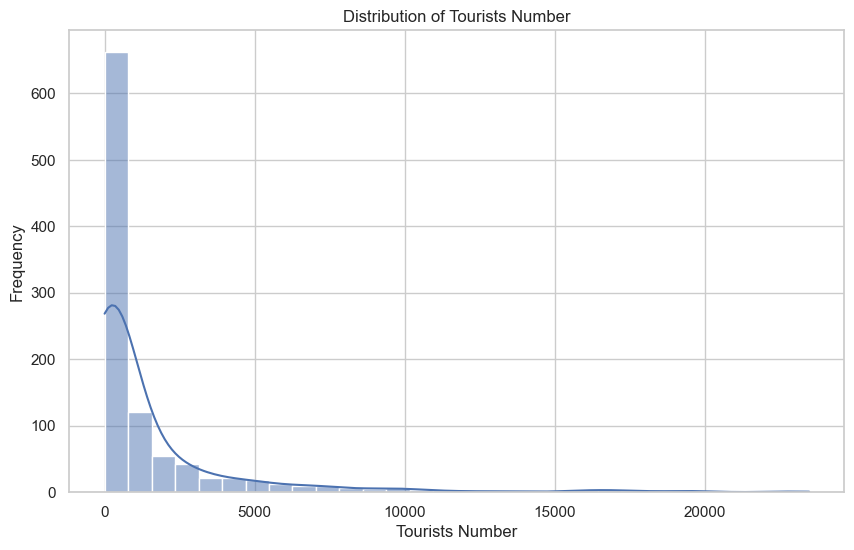

In [81]:
# Distribution of tourists number
sns.histplot(df["Tourists_Number"], bins=30, kde=True)

plt.title("Distribution of Tourists Number")
plt.xlabel("Tourists Number")
plt.ylabel("Frequency")
plt.show()

Most tourism records have a relatively small number of tourists, while a few records have very high tourist numbers. This means the data is right-skewed, where some provinces or years attract much more tourists than others.

Tourism Spending Distribution

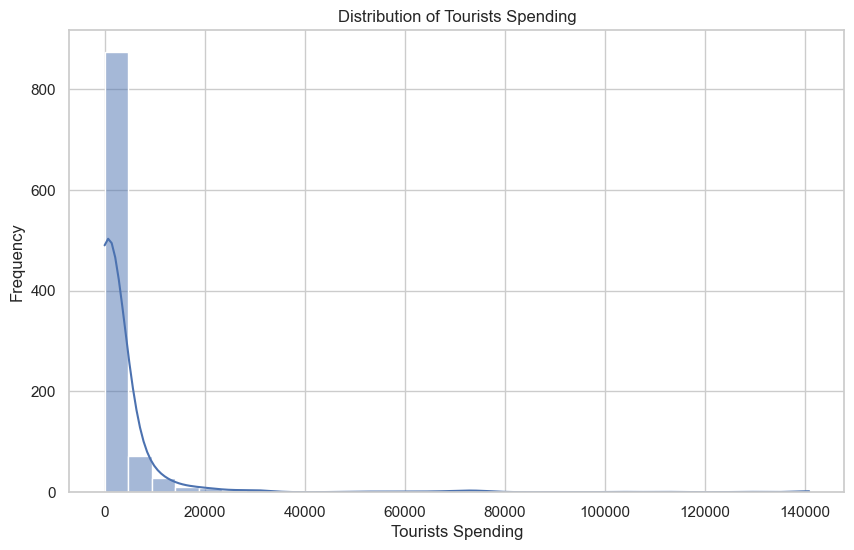

In [82]:
# Distribution of tourists spending
sns.histplot(df["Tourists_Spending"], bins=30, kde=True)

plt.title("Distribution of Tourists Spending")
plt.xlabel("Tourists Spending")
plt.ylabel("Frequency")
plt.show()

Most spending values are low to moderate, but there are a few very high spending records. This suggests that some regions or tourism types generate much higher revenue than others.

Average Stay Distribution

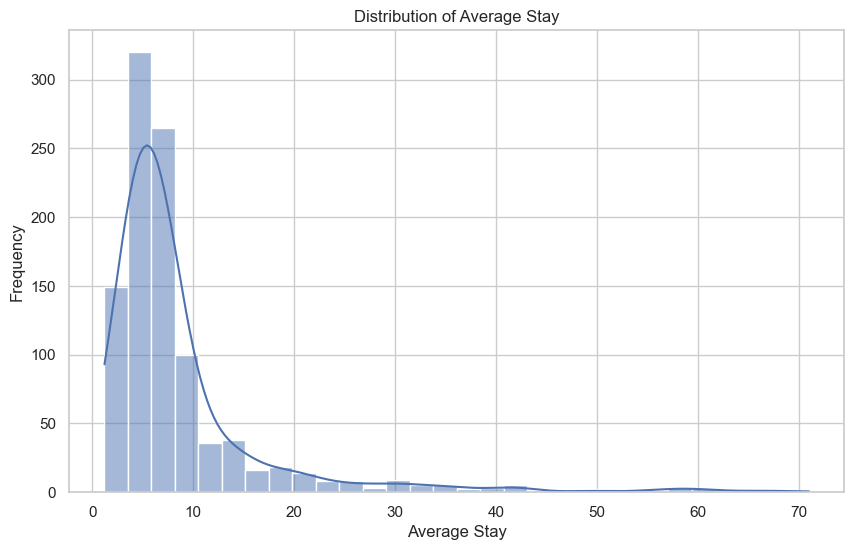

In [83]:
# Distribution of average stay
sns.histplot(df["Avg_Stay"], bins=30, kde=True)

plt.title("Distribution of Average Stay")
plt.xlabel("Average Stay")
plt.ylabel("Frequency")
plt.show()

Most average stays are short, but some records show very long stays. This may indicate special tourism categories or specific regions where visitors stay longer.

Log distribution of spending per tourist

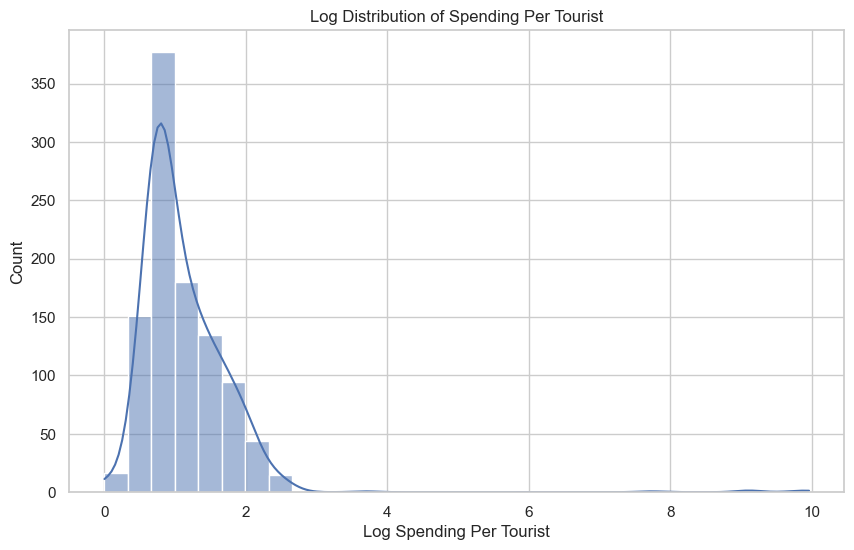

In [84]:
sns.histplot(
    np.log1p(df["Spending_Per_Tourist"]),
    bins=30,
    kde=True
)

plt.title("Log Distribution of Spending Per Tourist")
plt.xlabel("Log Spending Per Tourist")
plt.show()

The original distribution was heavily influenced by outliers. After applying a log transformation, the data became easier to interpret and showed that most tourists have relatively similar spending levels, while only a small number contribute exceptionally high spending.

## 5. Explore tourism trends over time
Tourist Numbers Over Years

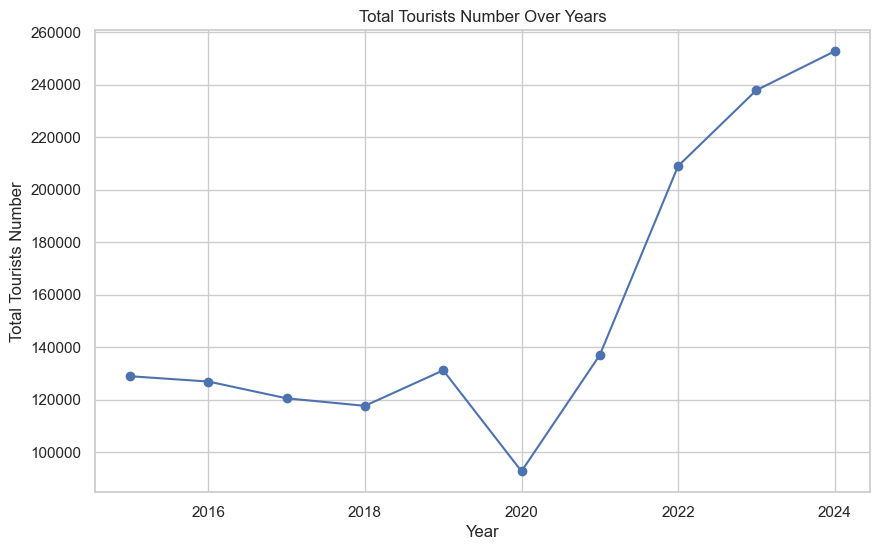

In [85]:
# Total tourists number by year
yearly_tourists = df.groupby("YEARS")["Tourists_Number"].sum()

yearly_tourists.plot(marker="o")

plt.title("Total Tourists Number Over Years")
plt.xlabel("Year")
plt.ylabel("Total Tourists Number")
plt.show()

The total number of tourists remained relatively stable between 2015 and 2019, followed by a sharp decline in 2020. After 2020, tourist numbers increased rapidly and reached their highest level in 2024. This indicates a strong recovery and growth in tourism activity after the pandemic period.

Tourism Spending Over Years

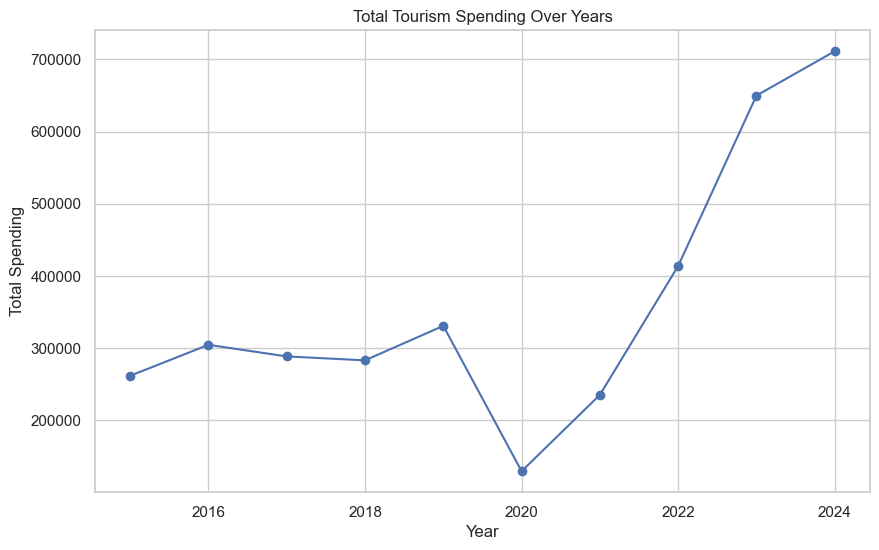

In [86]:
# Total tourism spending by year
yearly_spending = df.groupby("YEARS")["Tourists_Spending"].sum()

yearly_spending.plot(marker="o")

plt.title("Total Tourism Spending Over Years")
plt.xlabel("Year")
plt.ylabel("Total Spending")
plt.show()

Tourism spending dropped dramatically in 2020 but experienced strong growth afterward, reaching a record high in 2024. This indicates a significant recovery and expansion of the tourism sector in recent years.

Overnight Stay Over Years

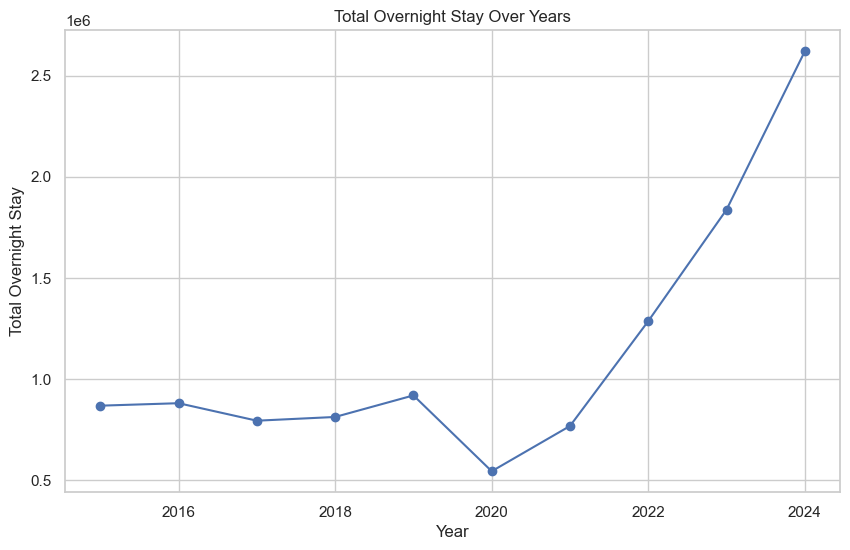

In [87]:
# Total overnight stays by year
yearly_overnight = df.groupby("YEARS")["Overnight_Stay"].sum()

yearly_overnight.plot(marker="o")

plt.title("Total Overnight Stay Over Years")
plt.xlabel("Year")
plt.ylabel("Total Overnight Stay")
plt.show()

Overnight stays declined noticeably in 2020 and then increased significantly in the following years. This trend suggests a strong recovery in tourism activity and visitor engagement after the pandemic period.

## 6. Compare tourism by province
Top Provinces by Tourists Number

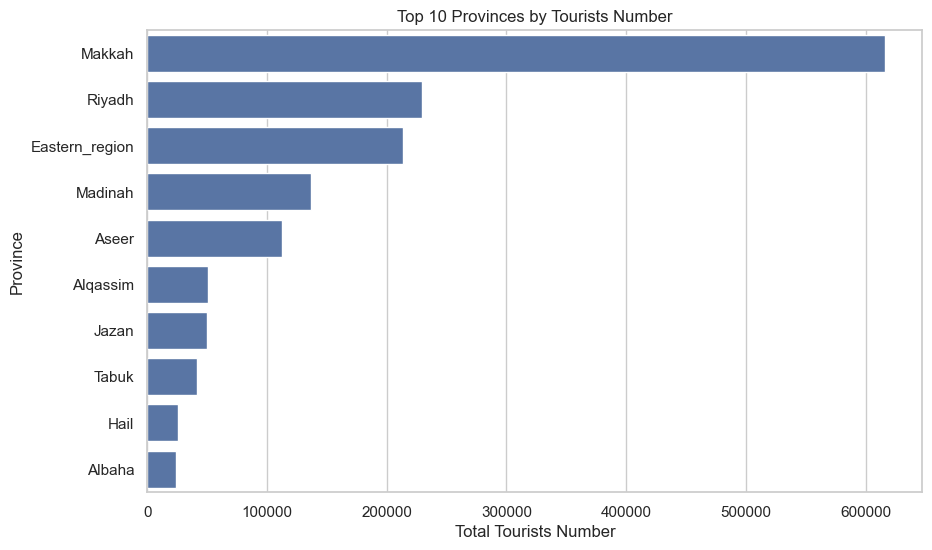

In [88]:
# Top 10 provinces by tourists number
top_provinces = (
    df.groupby("Province")["Tourists_Number"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

sns.barplot(
    x=top_provinces.values,
    y=top_provinces.index
)

plt.title("Top 10 Provinces by Tourists Number")
plt.xlabel("Total Tourists Number")
plt.ylabel("Province")
plt.show()

This chart shows the top 10 provinces by total number of tourists. Makkah attracts by far the highest number of tourists, followed by Riyadh and the Eastern Region. The large gap between Makkah and the remaining provinces suggests that tourism activity is highly concentrated in a few key destinations. This may be due to religious tourism and the strong tourism infrastructure in these provinces.

Top Provinces by Tourism Spending

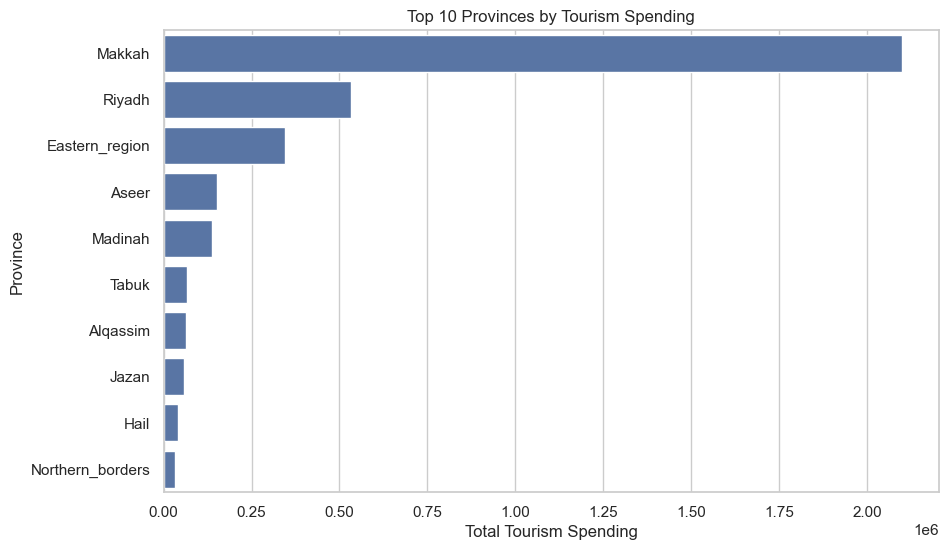

In [89]:
# Top 10 provinces by tourism spending
top_spending = (
    df.groupby("Province")["Tourists_Spending"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

sns.barplot(
    x=top_spending.values,
    y=top_spending.index
)

plt.title("Top 10 Provinces by Tourism Spending")
plt.xlabel("Total Tourism Spending")
plt.ylabel("Province")
plt.show()

Makkah has the highest tourism spending by a large margin, followed by Riyadh and the Eastern Region. This indicates that tourism revenue is concentrated in a small number of provinces, with Makkah being the dominant contributor.

## 7. Compare tourism types

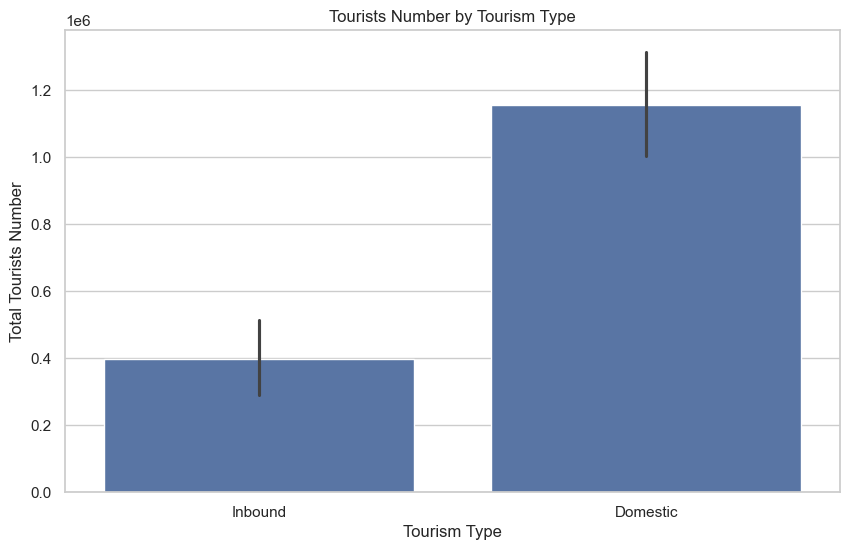

In [90]:
# Compare tourists number by tourism type
sns.barplot(
    data=df,
    x="Tourism_Type",
    y="Tourists_Number",
    estimator=sum
)

plt.title("Tourists Number by Tourism Type")
plt.xlabel("Tourism Type")
plt.ylabel("Total Tourists Number")
plt.show()

Domestic tourism attracts significantly more tourists than inbound tourism. The total number of domestic tourists is nearly three times higher than the number of inbound tourists, indicating that domestic tourism is the main contributor to tourism activity in Saudi Arabia. This highlights the important role of local travelers in supporting the tourism sector.

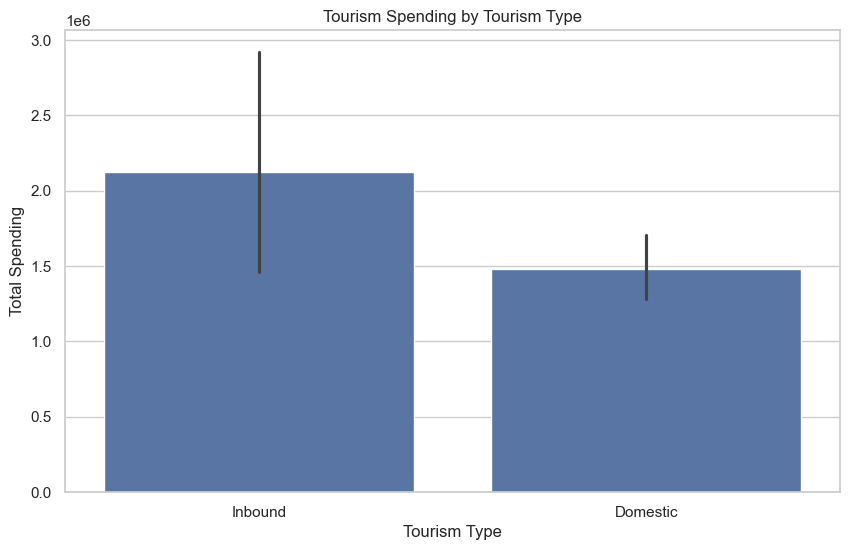

In [91]:
# Compare spending by tourism type
sns.barplot(
    data=df,
    x="Tourism_Type",
    y="Tourists_Spending",
    estimator=sum
)

plt.title("Tourism Spending by Tourism Type")
plt.xlabel("Tourism Type")
plt.ylabel("Total Spending")
plt.show()

Inbound tourism generates higher total tourism spending than domestic tourism, despite having fewer tourists. This suggests that inbound tourists tend to spend more per trip compared to domestic tourists. The difference indicates that international visitors contribute significantly to tourism revenue in Saudi Arabia.

## 8. Explore relationships between columns
Tourists Number vs Spending

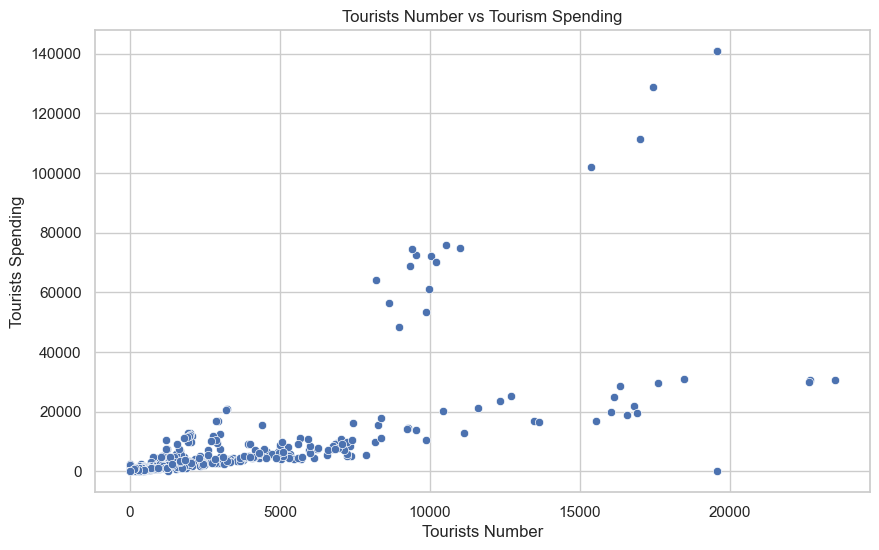

In [92]:
# Relationship between tourists number and spending
sns.scatterplot(
    data=df,
    x="Tourists_Number",
    y="Tourists_Spending"
)

plt.title("Tourists Number vs Tourism Spending")
plt.xlabel("Tourists Number")
plt.ylabel("Tourists Spending")
plt.show()

There is a positive correlation between tourist numbers and tourism spending, meaning that destinations attracting more tourists tend to generate higher tourism revenue.

Overnight Stay vs Spending

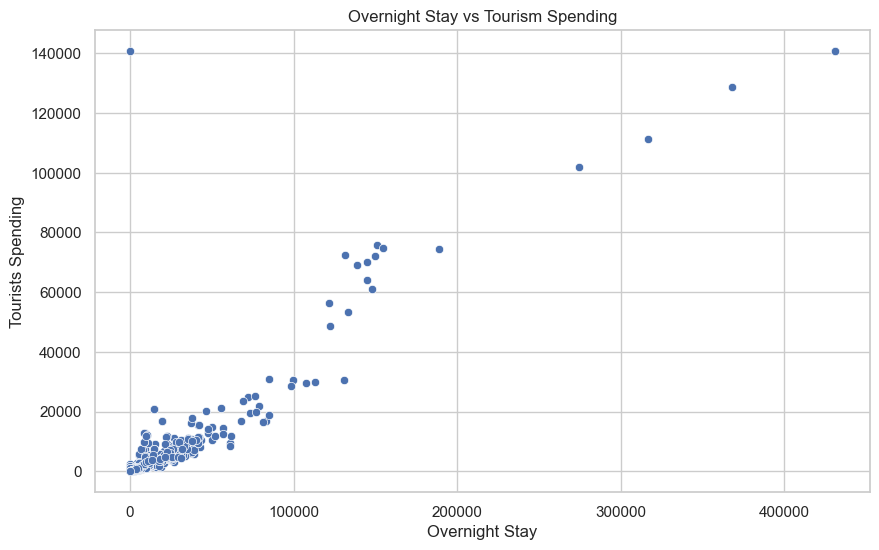

In [93]:
# Relationship between overnight stay and spending
sns.scatterplot(
    data=df,
    x="Overnight_Stay",
    y="Tourists_Spending"
)

plt.title("Overnight Stay vs Tourism Spending")
plt.xlabel("Overnight Stay")
plt.ylabel("Tourists Spending")
plt.show()

The relationship between overnight stays and tourism spending appears stronger than the relationship between tourist numbers and spending. This indicates that the duration of stay may have a significant impact on tourism revenue, as longer stays often lead to higher overall spending.

## 9. Correlation Heatmap

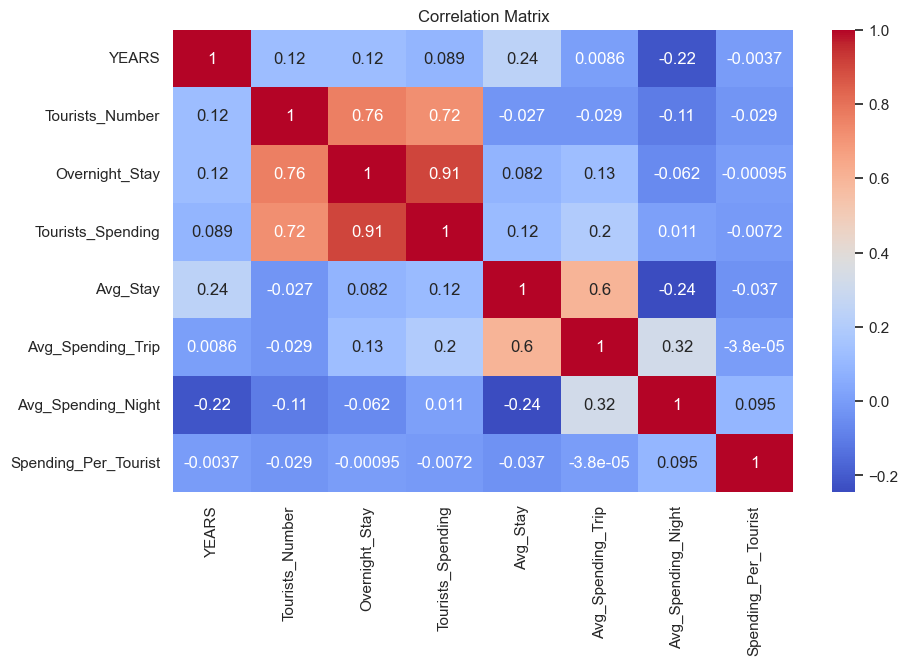

In [94]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Correlation heatmap
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

The strongest positive correlation is between Overnight Stay and Tourists Spending (0.91), indicating that longer tourist stays are strongly associated with higher tourism spending.

There is also a strong positive relationship between Tourists Number and Overnight Stay (0.76), as well as between Tourists Number and Tourists Spending (0.72). This suggests that destinations with more tourists tend to generate more overnight stays and higher tourism revenue.

In addition, Avg Stay and Avg Spending Trip show a moderate positive correlation (0.60), indicating that tourists who stay longer generally spend more per trip.

## 10. Outlier Analysis

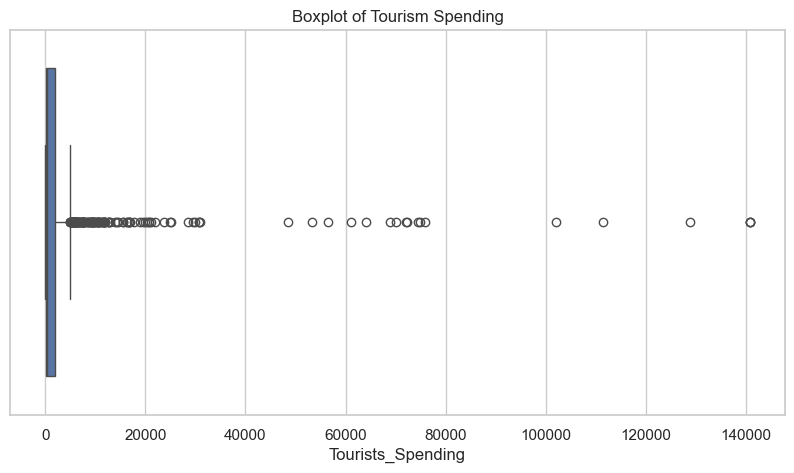

In [95]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["Tourists_Spending"]
)

plt.title("Boxplot of Tourism Spending")
plt.show()

The boxplot reveals a large number of outliers in the Tourists_Spending variable. Most observations are concentrated within a relatively small spending range, while several records show exceptionally high spending values. This indicates that tourism spending is highly right-skewed and that a small number of provinces or periods generate significantly higher tourism revenue than the majority of the dataset.

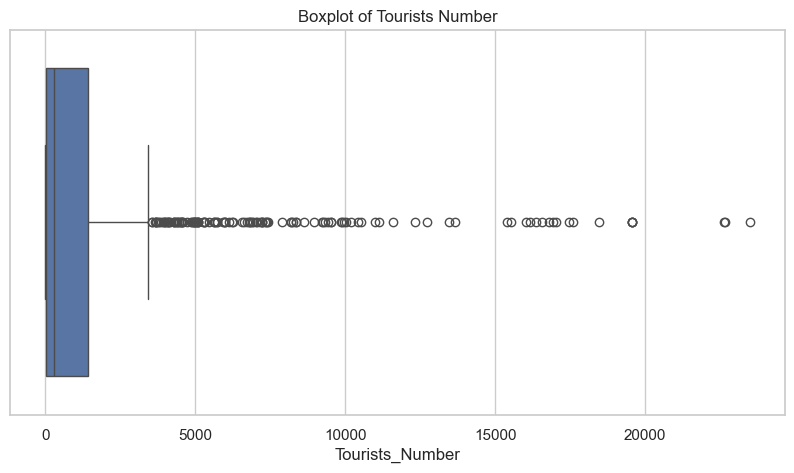

In [96]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["Tourists_Number"]
)

plt.title("Boxplot of Tourists Number")
plt.show()

A small number of provinces or periods attract significantly more tourists than the majority of observations. These high-value records are not necessarily errors and may represent major tourism destinations such as Makkah or Riyadh.

## Final Insights

1. Tourist numbers varied across provinces, with Makkah attracting the highest number of tourists by a significant margin, followed by Riyadh and the Eastern Region.

2. Tourism spending was highly concentrated in a few provinces, with Makkah generating the highest tourism revenue among all provinces.

3. Domestic tourism attracted substantially more tourists than inbound tourism, highlighting the important role of local travelers in Saudi Arabia's tourism sector.

4. Despite having fewer tourists, inbound tourism generated higher total spending than domestic tourism, indicating that international visitors tend to spend more per trip.

5. A positive relationship exists between tourist numbers and tourism spending, meaning that destinations with more tourists generally generate higher tourism revenue.

6. Overnight stays showed the strongest relationship with tourism spending (correlation = 0.91), suggesting that longer stays contribute significantly to tourism revenue.

7. Tourist numbers were strongly correlated with overnight stays (0.76) and tourism spending (0.72), indicating that higher visitor volumes are associated with increased tourism activity.

8. Average stay and average spending per trip showed a moderate positive relationship (0.60), suggesting that tourists who stay longer tend to spend more during their trips.

9. Tourism activity is not evenly distributed across Saudi Arabia, as a small number of provinces account for a large share of tourist arrivals and tourism spending.

10. The analysis highlights the importance of both visitor volume and length of stay in driving tourism revenue.

11. Tourist numbers declined sharply in 2020 and then increased rapidly between 2021 and 2024, reaching their highest level in 2024. This reflects the strong recovery of Saudi Arabia's tourism sector after the pandemic period.

12. Tourism spending followed a similar pattern, dropping significantly in 2020 before recovering and reaching a record high in 2024, indicating substantial growth in tourism revenue.

## Conclusion

This exploratory data analysis examined tourism trends in Saudi Arabia using data from 2015 to 2024. The analysis focused on tourist numbers, overnight stays, tourism spending, average stay duration, and spending behavior across different provinces and tourism types.

The results revealed significant differences between provinces, with Makkah emerging as the leading destination in both tourist arrivals and tourism spending. Domestic tourism attracted a larger number of visitors, while inbound tourism generated higher spending levels. The analysis also showed strong positive relationships between tourist numbers, overnight stays, and tourism spending.

Overall, the findings suggest that tourism revenue is influenced not only by the number of visitors but also by how long they stay and how much they spend. These insights provide a better understanding of tourism patterns in Saudi Arabia and highlight key factors that contribute to the growth of the tourism sector.
